<a href="https://colab.research.google.com/github/Deepakmittal03/Customer_Behavior_Analysis/blob/main/Customer_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (250000, 13)

Columns:
Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

Data Types:
Customer ID                int64
Purchase Date             object
Product Category          object
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method            object
Customer Age               int64
Returns                  float64
Customer Name             object
Age                        int64
Gender                    object
Churn                      int64
dtype: object

Missing Values:
Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Ret

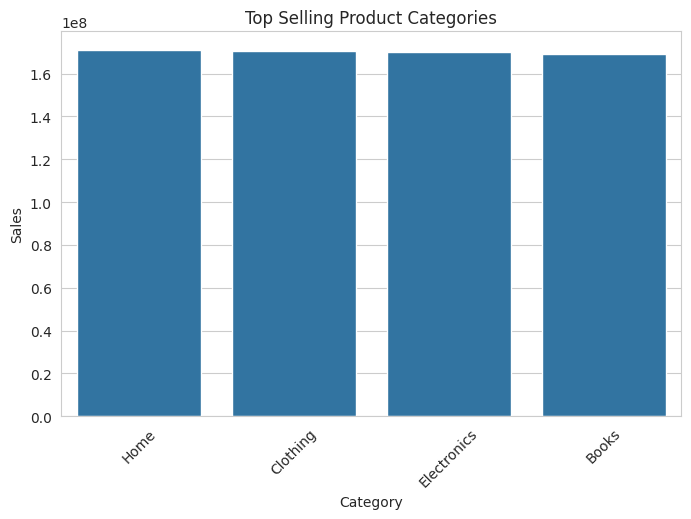

Payment Method
Credit Card    83547
PayPal         83441
Cash           83012
Name: count, dtype: int64


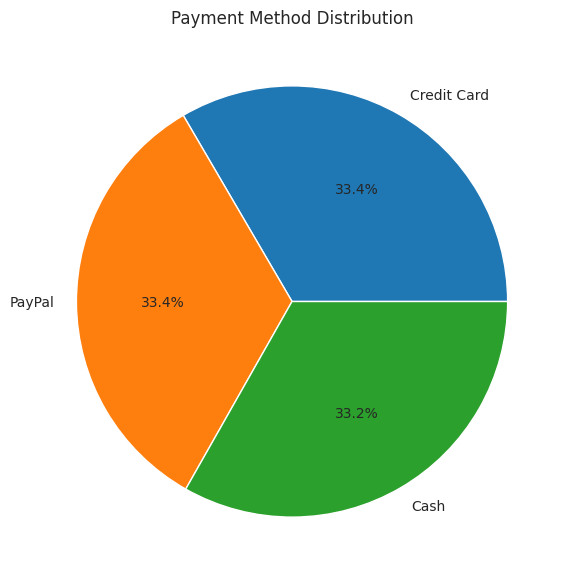

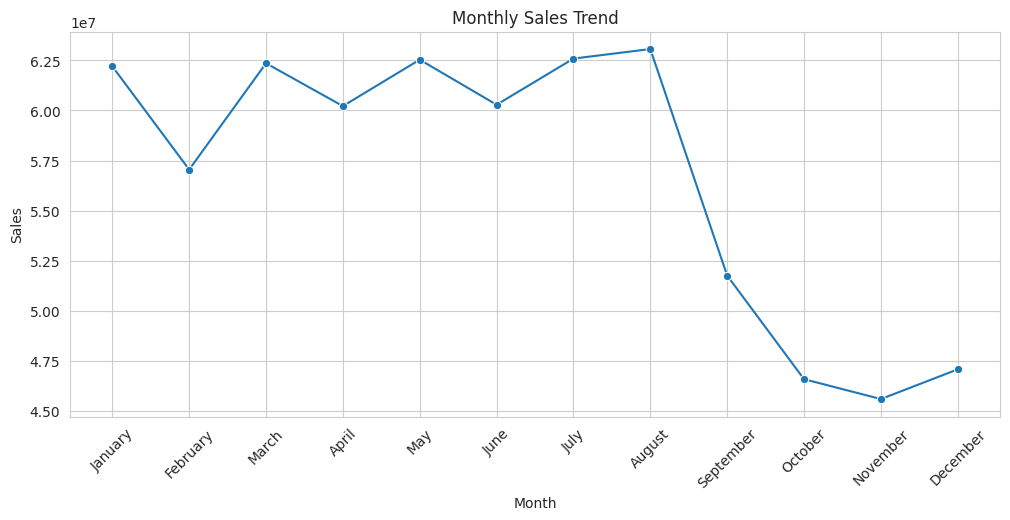

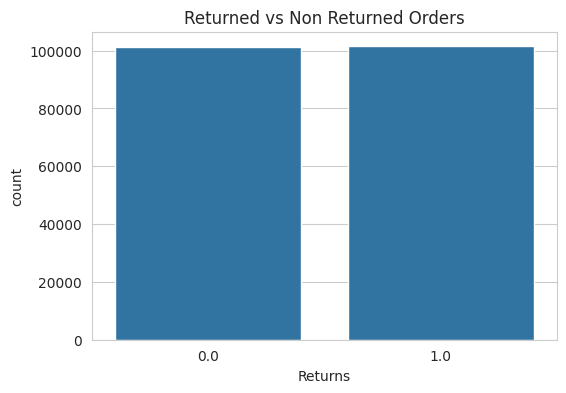


Return Distribution:
Returns
1.0    101476
0.0    101142
Name: count, dtype: int64


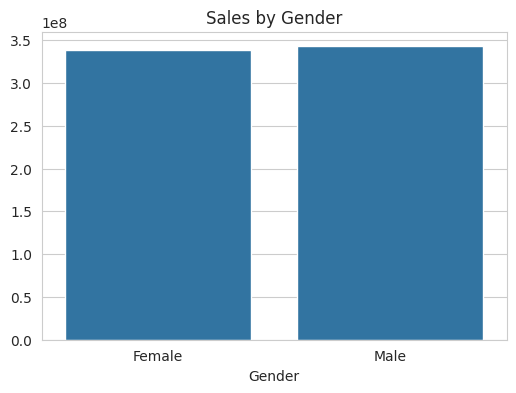

/tmp/ipykernel_5134/153096150.py:147: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age Group')['Total Purchase Amount'].sum()


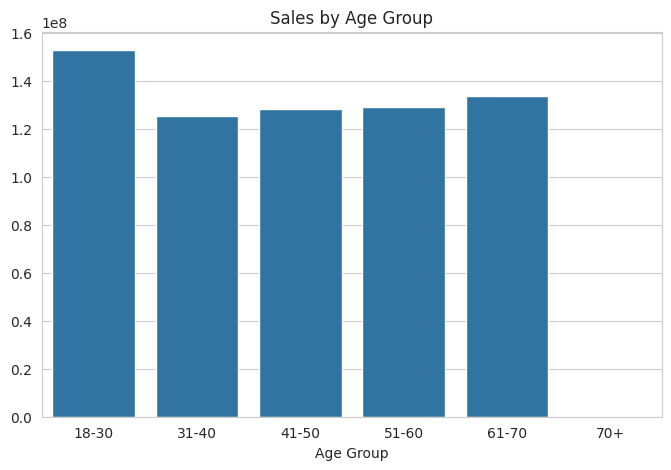


Age Group Sales:
Age Group
18-30    152694405
31-40    125214448
41-50    128224580
51-60    129154045
61-70    133574530
70+              0
Name: Total Purchase Amount, dtype: int64


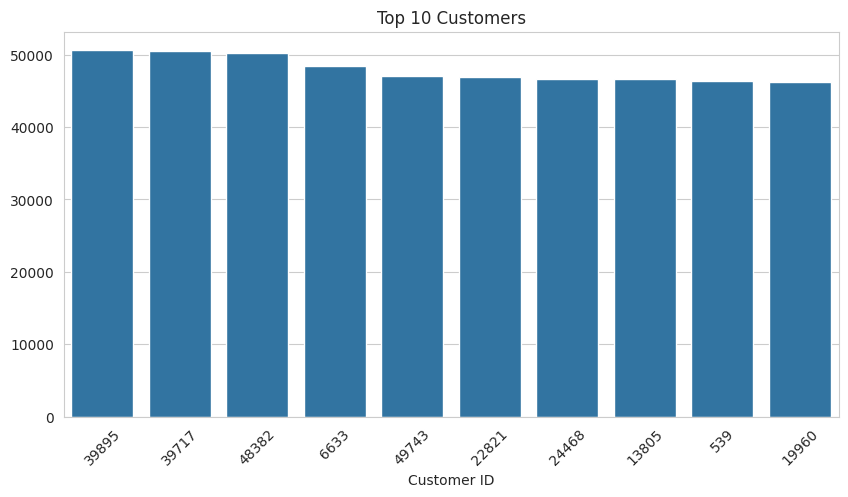

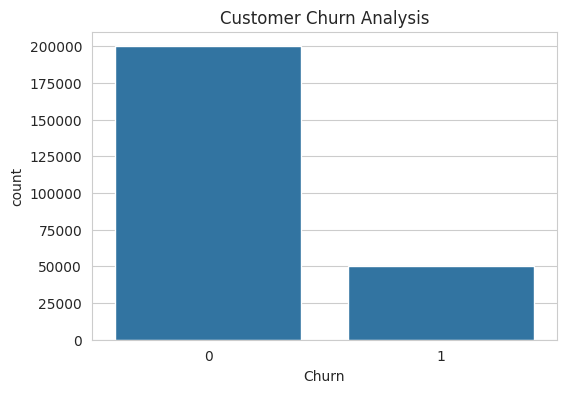


Churn Distribution:
Churn
0    199870
1     50130
Name: count, dtype: int64


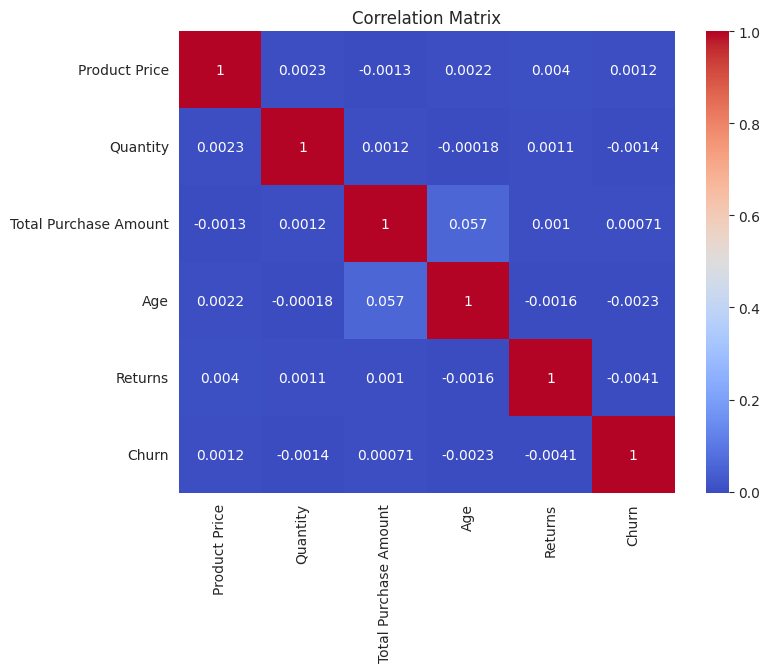


NumPy Analysis
Average Sale : 2725.385196
Maximum Sale : 5350
Minimum Sale : 100
Median Sale : 2725.0
Standard Deviation : 1442.5732095737956

----- BUSINESS INSIGHTS -----
1. Highest Revenue Categories Identified
2. Most Preferred Payment Method Found
3. Peak Sales Months Detected
4. Age Group Spending Behavior Analyzed
5. Customer Churn Examined
6. Return Patterns Evaluated
7. Top Customers Identified


In [4]:
# ==========================
# CUSTOMER BEHAVIOR ANALYSIS
# ==========================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load Dataset
df = pd.read_csv("ecommerce_customer_data_large.csv")

# ==========================
# BASIC DATA EXPLORATION
# ==========================

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

# ==========================
# DATA CLEANING
# ==========================

# Remove Duplicates
df.drop_duplicates(inplace=True)

# Convert Purchase Date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Extract Month
df['Month'] = df['Purchase Date'].dt.month_name()

print("Cleaned Shape:", df.shape)

# ==========================
# TOP SELLING CATEGORIES
# ==========================

top_categories = df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)

print("\nTop Categories:")
print(top_categories)

plt.figure(figsize=(8,5))
sns.barplot(x=top_categories.index,
            y=top_categories.values)

plt.title("Top Selling Product Categories")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# ==========================
# PAYMENT METHOD ANALYSIS
# ==========================

payment_counts = df['Payment Method'].value_counts()

print(payment_counts)

plt.figure(figsize=(7,7))
plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title("Payment Method Distribution")
plt.show()

# ==========================
# MONTHLY SALES TREND
# ==========================

monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_sales.index,
             y=monthly_sales.values,
             marker='o')

plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.ylabel("Sales")
plt.show()

# ==========================
# RETURNS ANALYSIS
# ==========================

returns = df['Returns'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x='Returns', data=df)

plt.title("Returned vs Non Returned Orders")
plt.show()

print("\nReturn Distribution:")
print(returns)

# ==========================
# GENDER ANALYSIS
# ==========================

gender_sales = df.groupby('Gender')['Total Purchase Amount'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=gender_sales.index,
            y=gender_sales.values)

plt.title("Sales by Gender")
plt.show()

# ==========================
# AGE GROUP ANALYSIS
# ==========================

bins = [18,30,40,50,60,70,100]
labels = ['18-30','31-40','41-50','51-60','61-70','70+']

df['Age Group'] = pd.cut(df['Age'],
                         bins=bins,
                         labels=labels)

age_sales = df.groupby('Age Group')['Total Purchase Amount'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=age_sales.index,
            y=age_sales.values)

plt.title("Sales by Age Group")
plt.show()

print("\nAge Group Sales:")
print(age_sales)

# ==========================
# TOP 10 CUSTOMERS
# ==========================

top_customers = (
    df.groupby('Customer ID')['Total Purchase Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers.values
)

plt.title("Top 10 Customers")
plt.xticks(rotation=45)
plt.show()

# ==========================
# CHURN ANALYSIS
# ==========================

churn_data = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Analysis")
plt.show()

print("\nChurn Distribution:")
print(churn_data)

# ==========================
# CORRELATION HEATMAP
# ==========================

numeric_cols = [
    'Product Price',
    'Quantity',
    'Total Purchase Amount',
    'Age',
    'Returns',
    'Churn'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

# ==========================
# NUMPY ANALYSIS
# ==========================

sales = np.array(df['Total Purchase Amount'])

print("\nNumPy Analysis")
print("Average Sale :", np.mean(sales))
print("Maximum Sale :", np.max(sales))
print("Minimum Sale :", np.min(sales))
print("Median Sale :", np.median(sales))
print("Standard Deviation :", np.std(sales))

# ==========================
# FINAL BUSINESS INSIGHTS
# ==========================

print("\n----- BUSINESS INSIGHTS -----")
print("1. Highest Revenue Categories Identified")
print("2. Most Preferred Payment Method Found")
print("3. Peak Sales Months Detected")
print("4. Age Group Spending Behavior Analyzed")
print("5. Customer Churn Examined")
print("6. Return Patterns Evaluated")
print("7. Top Customers Identified")

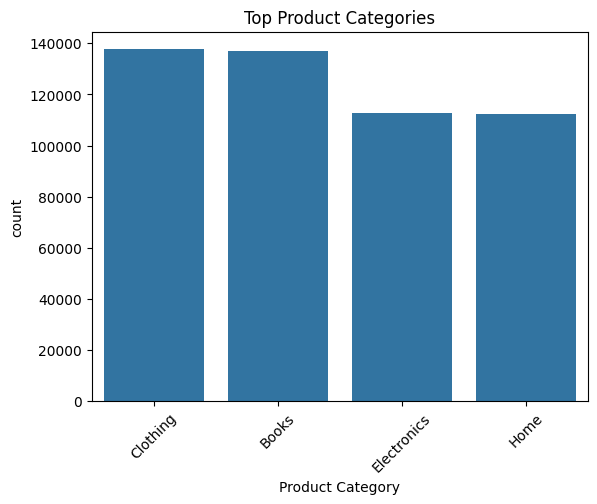

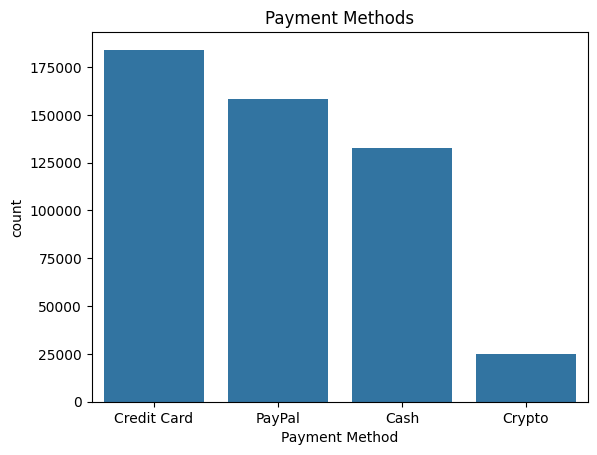

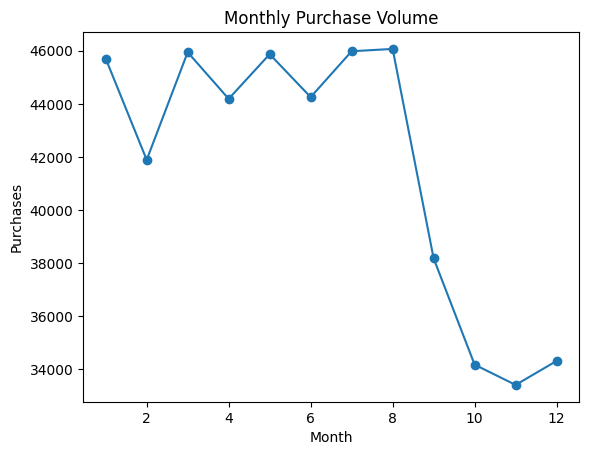

/tmp/ipykernel_5134/3965641620.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = df.groupby('Age Group')['Total Purchase Amount'].mean().reset_index()
/tmp/ipykernel_5134/3965641620.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age Group', y='Total Purchase Amount', data=age_spend, palette='coolwarm')


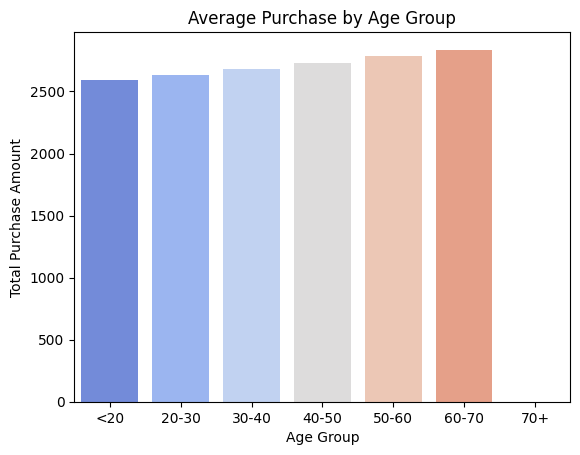